<h1> Forest Fire Analysis</h1>
<h2> Project Objective</h2>
<h3> The purpose of this project is to explore the factors associated with the area burned by forest fires.

The analysis focuses on the following weather variables:

- Temperature
- Relative humidity
- Wind speed
- Rainfall

The projectt includes exploratory data analysis, correlation, data visualization and a multiple linear regression model.

</h3>


In [1]:
# Data manipulation
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Statistical analysis
import statsmodels.api as sm

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
# Loading dataset
forest_df = pd.read_csv("forestfires.csv")

# Displaying first 5 rows
forest_df.head()

,X,Y,month,day,FFMC,DMC,DC,ISI,temp,RH,wind,rain,area
0,7,5,mar,fri,86.2,26.2,94.3,5.1,8.2,51,6.7,0.0,0.0
1,7,4,oct,tue,90.6,35.4,669.1,6.7,18.0,33,0.9,0.0,0.0
2,7,4,oct,sat,90.6,43.7,686.9,6.7,14.6,33,1.3,0.0,0.0
3,8,6,mar,fri,91.7,33.3,77.5,9.0,8.3,97,4.0,0.2,0.0
4,8,6,mar,sun,89.3,51.3,102.2,9.6,11.4,99,1.8,0.0,0.0


## 1. Performing eploratory data inspection

In [3]:
forest_df.shape
print(f"Number of observations: {forest_df.shape[0]}")
print(f"Number of atributes: {forest_df.shape[1]}")

Number of observations: 517
Number of atributes: 13


In [4]:
forest_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 517 entries, 0 to 516
Data columns (total 13 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   X       517 non-null    int64  
 1   Y       517 non-null    int64  
 2   month   517 non-null    object 
 3   day     517 non-null    object 
 4   FFMC    517 non-null    float64
 5   DMC     517 non-null    float64
 6   DC      517 non-null    float64
 7   ISI     517 non-null    float64
 8   temp    517 non-null    float64
 9   RH      517 non-null    int64  
 10  wind    517 non-null    float64
 11  rain    517 non-null    float64
 12  area    517 non-null    float64
dtypes: float64(8), int64(3), object(2)
memory usage: 52.6+ KB


In [5]:
# Showing basic stats
forest_df.describe().round(2)

,X,Y,FFMC,DMC,DC,ISI,temp,RH,wind,rain,area
count,517.00,517.00,517.00,517.00,517.00,517.00,517.00,517.00,517.00,517.00,517.00
mean,4.67,4.30,90.64,110.87,547.94,9.02,18.89,44.29,4.02,0.02,12.85
std,2.31,1.23,5.52,64.05,248.07,4.56,5.81,16.32,1.79,0.30,63.66
min,1.00,2.00,18.70,1.10,7.90,0.00,2.20,15.00,0.40,0.00,0.00
25%,3.00,4.00,90.20,68.60,437.70,6.50,15.50,33.00,2.70,0.00,0.00
50%,4.00,4.00,91.60,108.30,664.20,8.40,19.30,42.00,4.00,0.00,0.52
75%,7.00,5.00,92.90,142.40,713.90,10.80,22.80,53.00,4.90,0.00,6.57
max,9.00,9.00,96.20,291.30,860.60,56.10,33.30,100.00,9.40,6.40,1090.84


<h3>Finding missing values and duplicate records</h3>

In [6]:
# finding missing values
missing = forest_df.isnull().sum()
total_number_missing_values = forest_df.isnull().sum().sum()

print(missing)
print(f"The total number of missing values is: {total_number_missing_values}")

X        0
Y        0
month    0
day      0
FFMC     0
DMC      0
DC       0
ISI      0
temp     0
RH       0
wind     0
rain     0
area     0
dtype: int64
The total number of missing values is: 0


In [7]:
# Finding duplicates
duplicates = forest_df.duplicated().sum()

print(f"Number of duplicate rows: {duplicates}")


# Display duplicates
forest_df[forest_df.duplicated()]

Number of duplicate rows: 4


,X,Y,month,day,FFMC,DMC,DC,ISI,temp,RH,wind,rain,area
53,4,3,aug,wed,92.1,111.2,654.1,9.6,20.4,42,4.9,0.0,0.00
100,3,4,aug,sun,91.4,142.4,601.4,10.6,19.8,39,5.4,0.0,0.00
215,4,4,mar,sat,91.7,35.8,80.8,7.8,17.0,27,4.9,0.0,28.66
303,3,6,jun,fri,91.1,94.1,232.1,7.1,19.2,38,4.5,0.0,0.00


<h3> For the duplicate records shown above, as they represent less than the 1% of the data, they will remain and will not be dropped.</h3>

## 2. Exploring Categorical Variables

In [8]:
# Number of observations per month
forest_df['month'].value_counts()

month
aug    184
sep    172
mar     54
jul     32
feb     20
jun     17
oct     15
apr      9
dec      9
jan      2
may      2
nov      1
Name: count, dtype: int64

<h3>Month Distribution</h3>

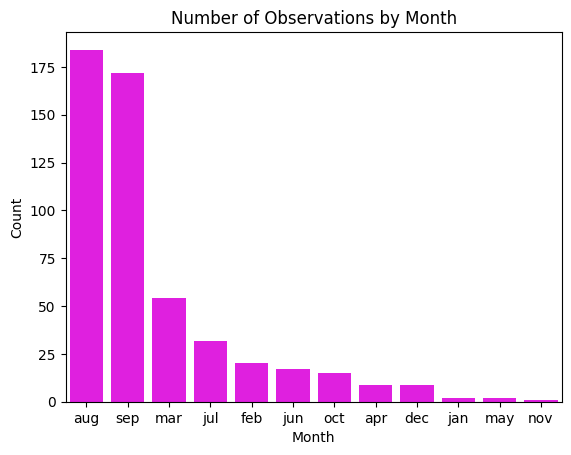

In [9]:
# Graph of number of observations per month
plt.Figure(figsize=(10, 4))

sns.countplot( data=forest_df, x='month', order=forest_df['month'].value_counts().index, color='magenta')

plt.title('Number of Observations by Month')
plt.xlabel('Month')
plt.ylabel('Count')

plt.show()

<h3>Week Distribution</h3>

In [10]:
# Number of observations per days
forest_df['day'].value_counts()

day
sun    95
fri    85
sat    84
mon    74
tue    64
thu    61
wed    54
Name: count, dtype: int64

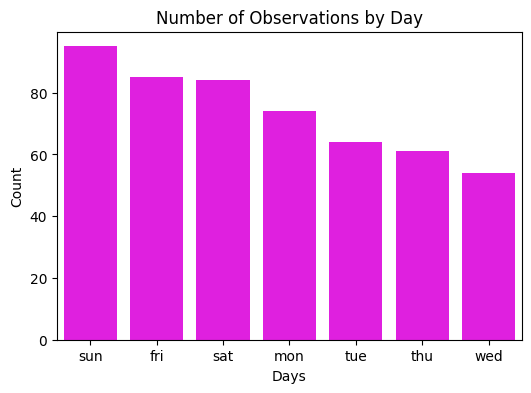

In [11]:
# Graph of number observations per day
plt.figure(figsize=(6,4))

sns.countplot(data=forest_df, x='day', order=forest_df['day'].value_counts().index,color='magenta')

plt.title('Number of Observations by Day')
plt.xlabel('Days')
plt.ylabel('Count')

plt.show()

<h3>

<h3>After analyzing the distribution per month and day, we can conclude that the highest month were August and September. And regarding the days, they are look more balance across the whole week.</h3>

## 3. Exploring Numerical Variables

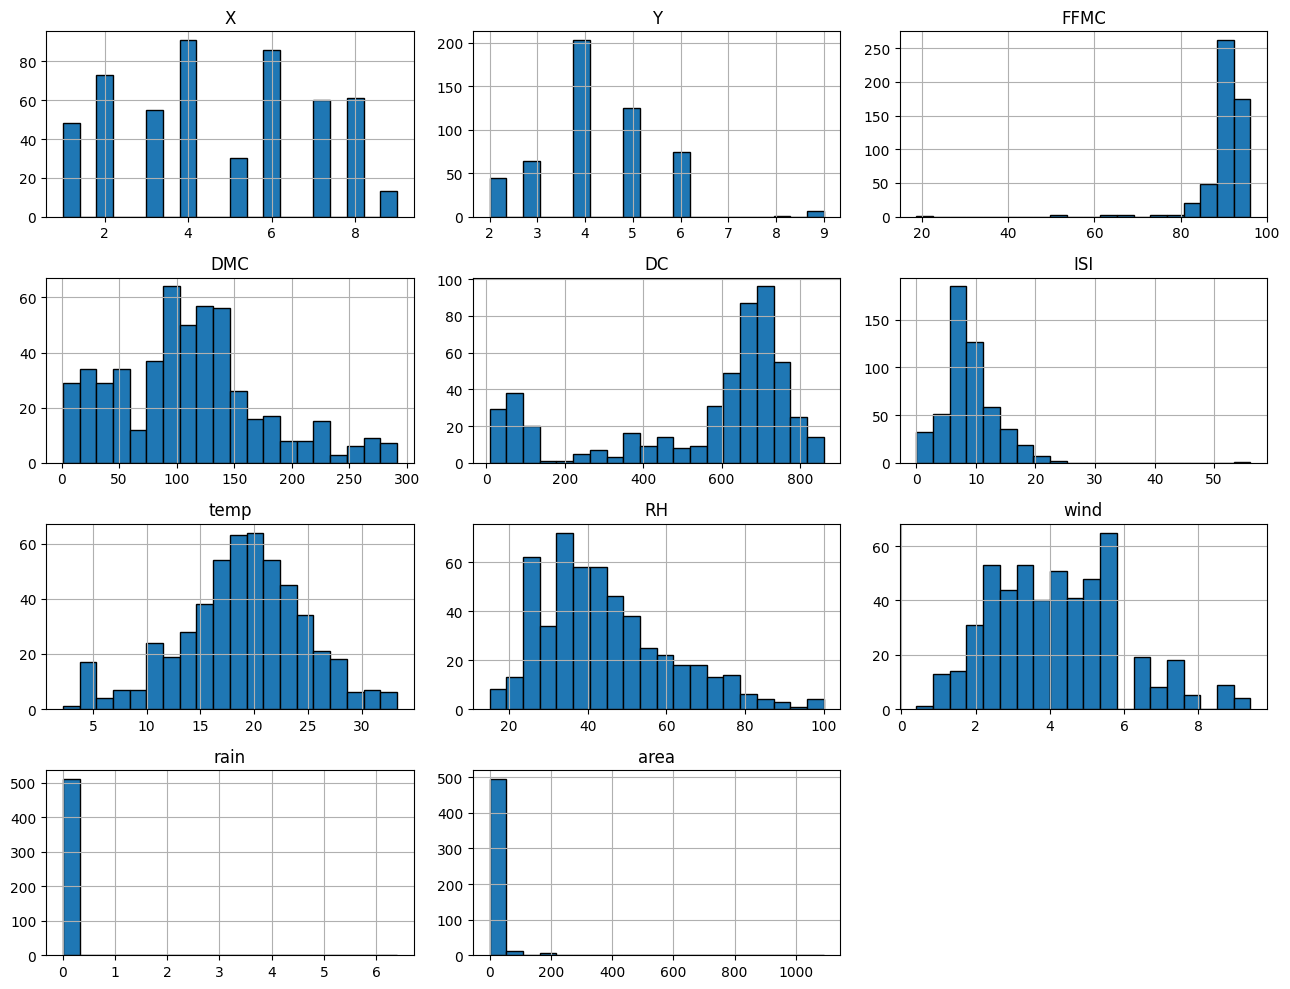

In [12]:
# Generating all histograms together
forest_df.hist( figsize=(13,10), bins=20, edgecolor='black')

plt.tight_layout()
plt.show()

<h3>'Temperature' is the only normal distribution, while 'area' (the dependent variable) is showing almost all the fires happening in small areas with just a few in large areas. </h3>

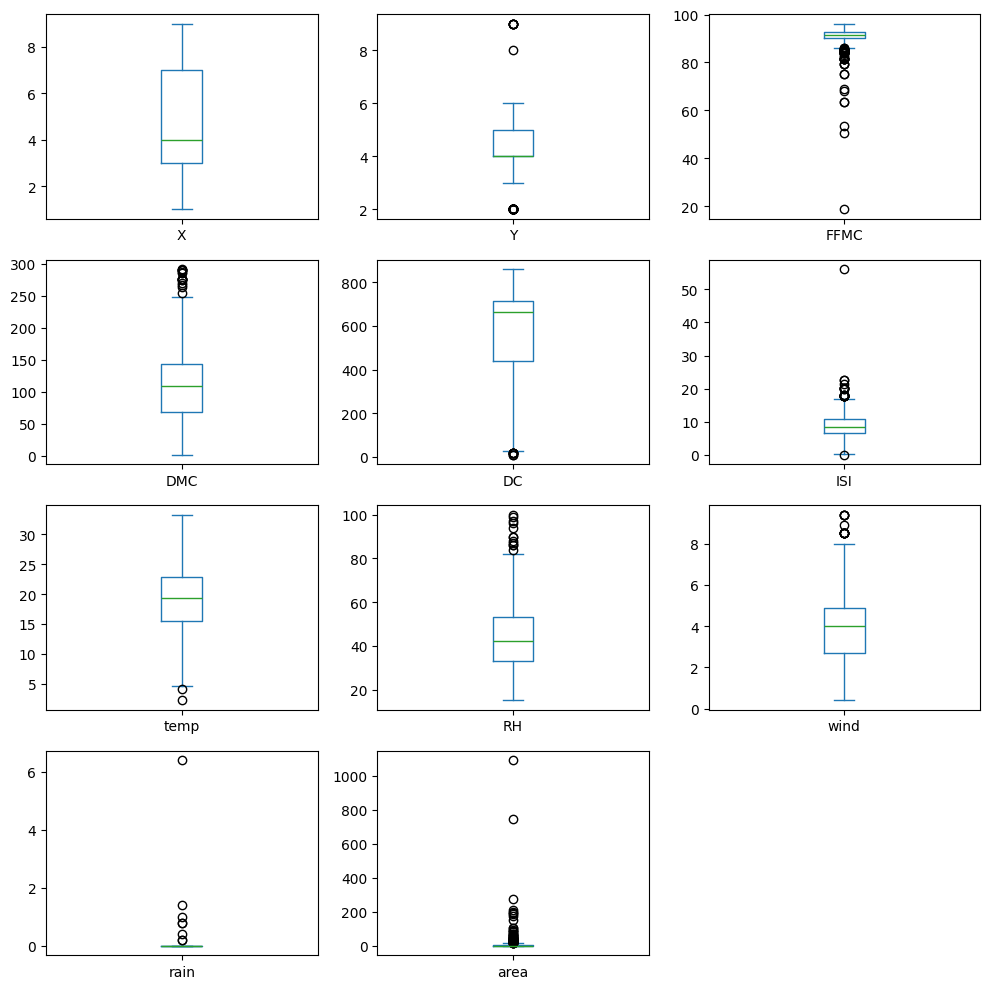

In [13]:
# Finding outliers
forest_df.plot(kind='box', subplots=True, layout=(4,3), figsize=(10,10))

plt.tight_layout()
plt.show()

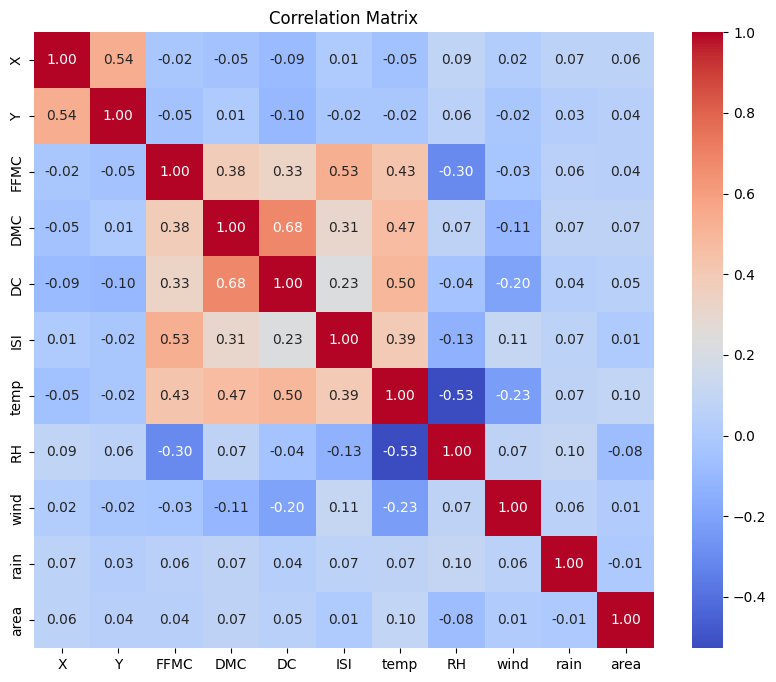

In [14]:
# Correlation matrix
plt.figure(figsize=(10,8))

correlation = forest_df.corr(numeric_only=True)

sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt='.2f')

plt.title('Correlation Matrix')
plt.show()

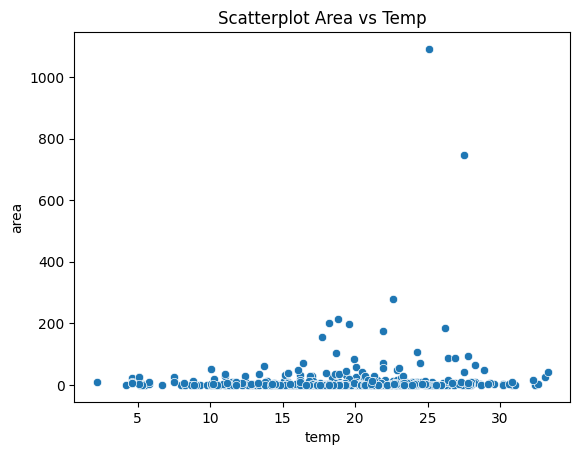

In [15]:
# Scatterplot 1
sns.scatterplot(data=forest_df, x='temp', y='area')

plt.title('Scatterplot Area vs Temp')
plt.show()

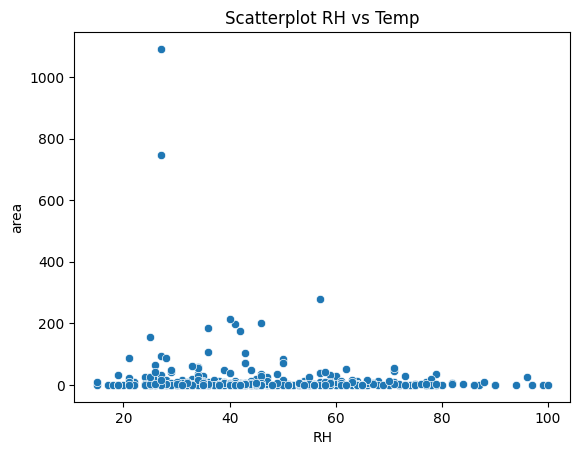

In [16]:
# Scatterplot 2
sns.scatterplot(data=forest_df, x='RH', y='area')

plt.title('Scatterplot RH vs Temp')
plt.show()

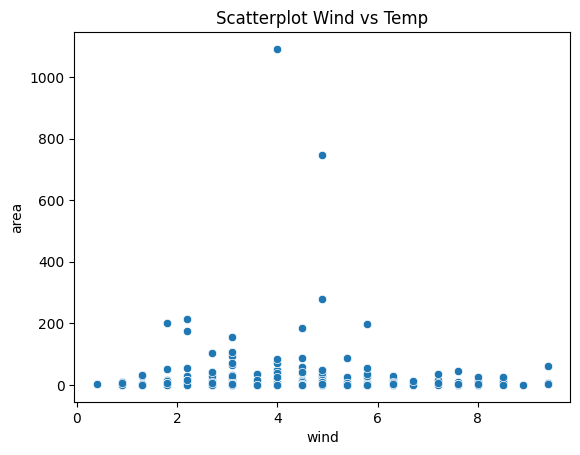

In [17]:
# Scatterplot 3
sns.scatterplot(data=forest_df, x='wind', y='area')

plt.title('Scatterplot Wind vs Temp')
plt.show()

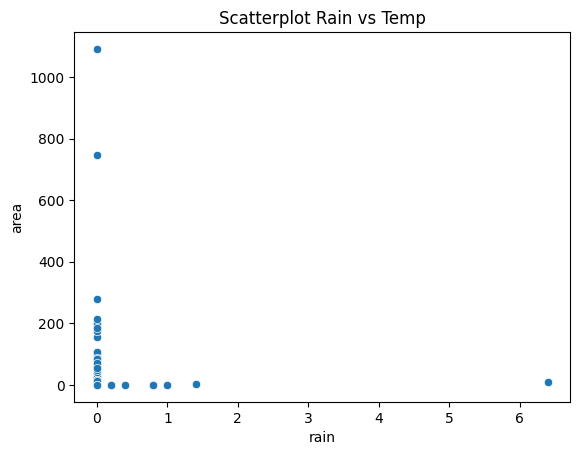

In [18]:
# Scatterplot 4
sns.scatterplot(data=forest_df, x='rain', y='area')

plt.title('Scatterplot Rain vs Temp')
plt.show()

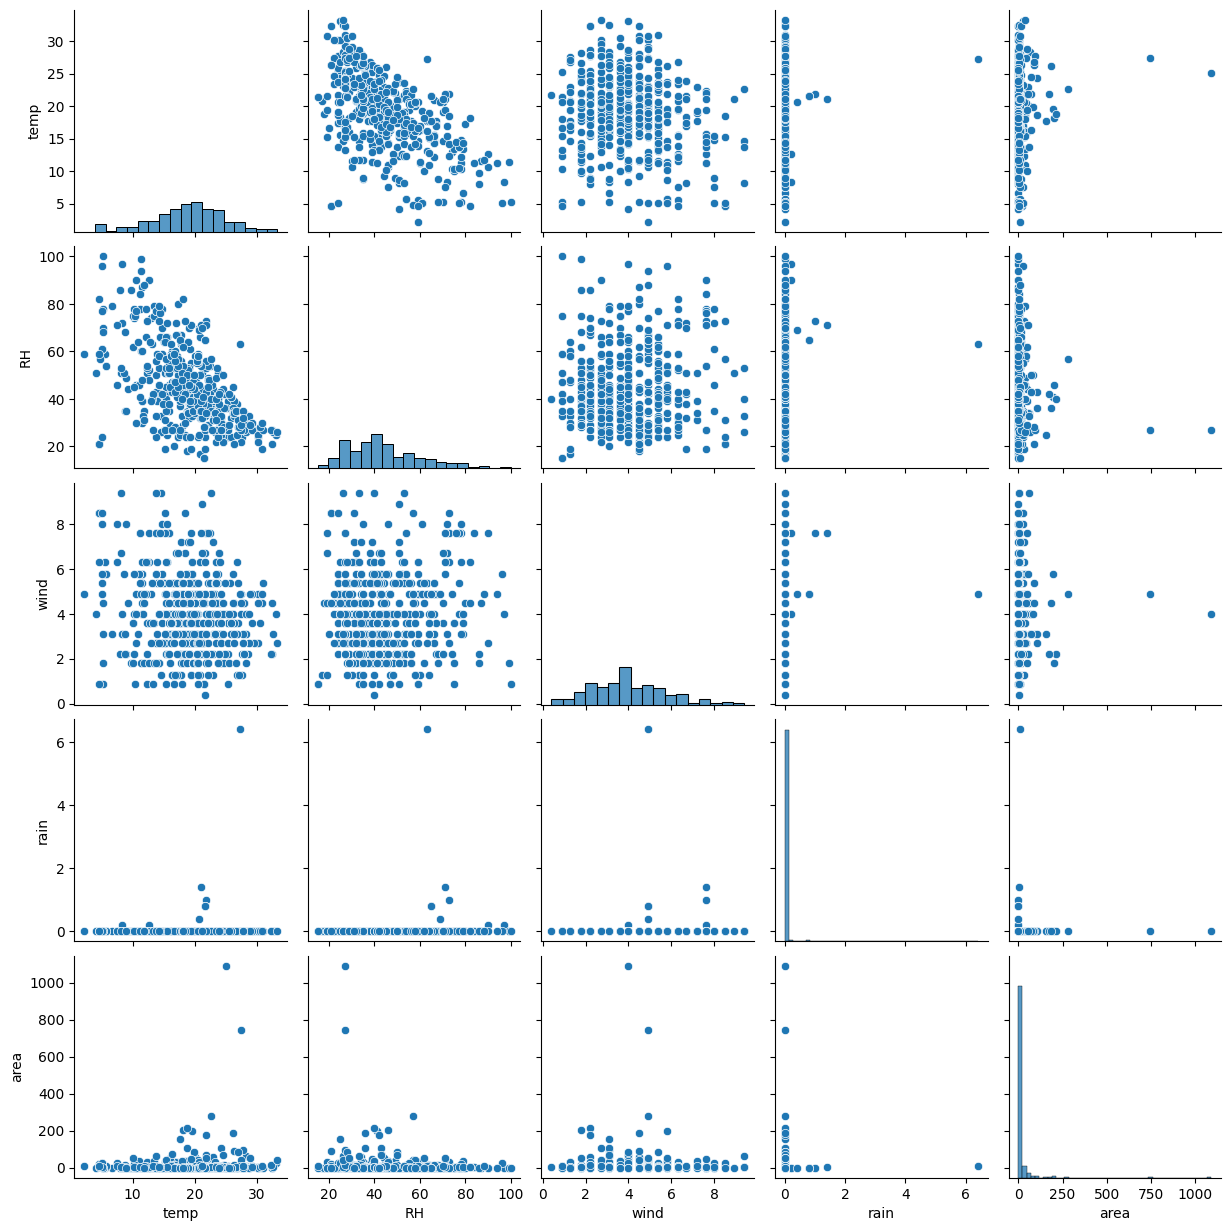

In [19]:
sns.pairplot(forest_df[['temp', 'RH', 'wind', 'rain', 'area']])

<h3>What we find from the scatterplots above is:</h3>
<h3>- Temperature and relative humidity have a strong negative relative in the dataset. That means that higher temperatures are associated with lower relative humidity.</h3> 
<h3>- Temperature and area seem to have a slight positive trend, meaning, larger burned areas tend to occurr at higher temperatures.</h3>
<h3>- Relative humidity and area seem to have a weak negative trend, meaning, larger fires are more frequently observed at lower humidity levels.</h3>
<h3>- Wind and area seem to have no linear relationship.</h3>
<h3>- Rain and area, well, rain is unlikely to contribute much to a linear regression model because it has very little variation.</h3>
<h3>- Lastly, area is extremely right-skewed, meaning, most of the fires ocurred in small areas.</h3>

## Building the regression model

In [20]:
# Let's define the independent variables
X = forest_df[['temp', 'RH', 'wind', 'rain']]

# Now the dependent
y = forest_df['area']

In [21]:
# Splitting the data between train and test
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

# Training the model
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train, y_train)

# Making predictions
y_predictor = model.predict(X_test)

# Evaluating the model
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_predictor)
mse = mean_squared_error(y_test, y_predictor)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_predictor)

print(f"MAE     : {mae:.2f}")
print(f"MSE     :{mse:.2f}")
print(f"RMSE    :{rmse:.2f}")
print(f"R2      :{r2:.3f}")


MAE     : 24.31
MSE     :11748.59
RMSE    :108.39
R2      :0.003


In [22]:
coefficients = pd.DataFrame({'Variable': X.columns,'Coefficient': model.coef_})

coefficients

,Variable,Coefficient
0,temp,0.868394
1,RH,0.000311
2,wind,0.970284
3,rain,-2.129517


In [23]:
print(f"Intercept: {model.intercept_:.2f}")

Intercept: -9.12


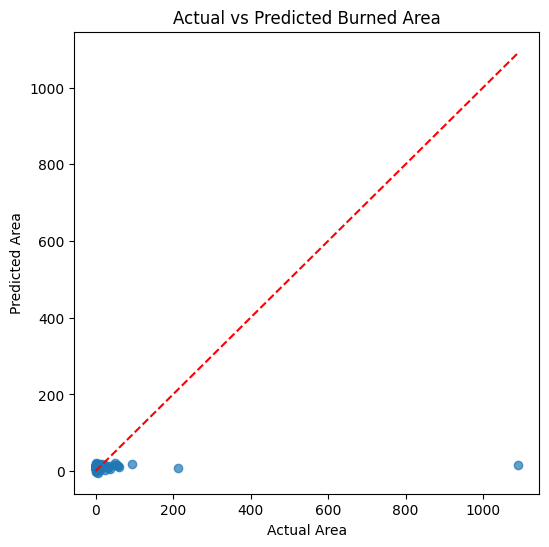

In [24]:
# Let's calculate the actual versus the predicted area

plt.figure(figsize=(6,6))

plt.scatter(y_test, y_predictor, alpha=0.7)

plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--')

plt.xlabel("Actual Area")
plt.ylabel("Predicted Area")
plt.title("Actual vs Predicted Burned Area")

plt.show()

<h2>Current status</h2>
<h3>This project demonstrates a complete exploratory data analysis and multiple linear regression workflow using the Forest Fires dataset.</h3>

<h3>Future improvements include:</h3>

<h3>-Applying a log transformation to the target variable('area')</h3>
<h3>-Evaluating regression assumptions</h3>
<h3>-Comparing additional machine learning models (e.b., Ranfom Forest)</h3>
<h3>-Performing feature engineering to improve predictive performance</h3>